In [7]:
import os
import sys
import cv2 

import torch 
import numpy as np 
import fiftyone as fo 
import fiftyone.zoo as foz 
import fiftyone.types as fot 
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

from PIL import Image
from torch.utils.data import DataLoader, Dataset 

sys.path.append(os.path.abspath("../../code/segment-anything"))
from segment_anything import sam_model_registry, SamPredictor

In [8]:
# Initialize SAM 
sam_checkpoint = r'C:\Users\ADMIN\Documents\SAM\Research\model\sam_vit_b_01ec64.pth'
model_type = 'vit_b' 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint) 
sam.to(device) 
predictor = SamPredictor(sam) 

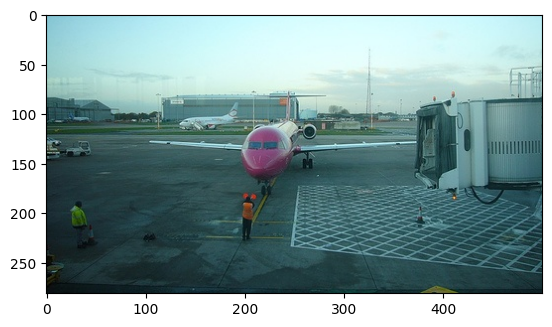

In [9]:
image_path = r'C:\Users\ADMIN\Documents\SAM\Research\src\Data\VOCtrainval_11-May-2012\VOCdevkit\VOC2012\JPEGImages\2007_000032.jpg'
semantic_image_path = r'C:\Users\ADMIN\Documents\SAM\Research\src\Data\VOCtrainval_11-May-2012\VOCdevkit\VOC2012\SegmentationObject\2007_000032.png'
annotations_path = r'C:\Users\ADMIN\Documents\SAM\Research\src\Data\VOCtrainval_11-May-2012\VOCdevkit\VOC2012\Annotations\2007_000032.xml'

image = np.array(Image.open(image_path)) 
plt.imshow(image)

In [10]:
tree = ET.parse(annotations_path) 
root = tree.getroot() 
canvas_width = root.find('size').find('width').text
canvas_height = root.find('size').find('height').text
print(canvas_width, canvas_height)

labels = []
bboxes = []
for obj in root.findall("object"): 
    label = obj.find('name').text
    x_min = int(obj.find('bndbox').find('xmin').text)
    y_min = int(obj.find('bndbox').find('ymin').text) 
    x_max = int(obj.find('bndbox').find('xmax').text) 
    y_max = int(obj.find('bndbox').find('ymax').text)  
    bbox = np.array([x_min, y_min, x_max, y_max])
    labels.append(label) 
    bboxes.append(bbox) 

    print(label, x_min, y_min, x_max, y_max)

for label, bbox in zip(labels, bboxes): 
    x_min, y_min, x_max, y_max = bbox 
    cv2.rectangle(
        img=image,
        pt1=(x_min, y_min), 
        pt2=(x_max, y_max),
        color=(200, 0, 0),
        thickness=2      
    )
    cv2.putText(
        img=image,
        text=label, 
        org=(x_min, y_min - 10 if y_min > 0 else y_min),
        fontFace=cv2.FONT_HERSHEY_SIMPLEX,\
        fontScale=0.6,
        color=(0, 200, 0), 
        thickness=1
        )


500 281
aeroplane 104 78 375 183
aeroplane 133 88 197 123
person 195 180 213 229
person 26 189 44 238


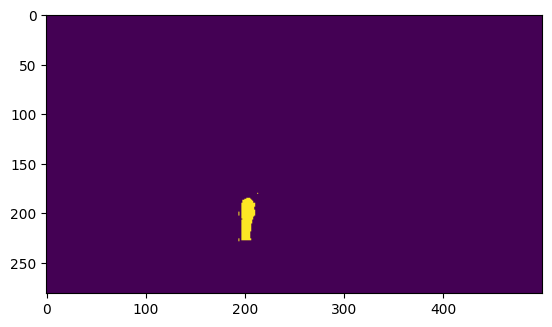

In [11]:
input_sam_bbox = np.array([195, 180, 213, 229])
predictor.set_image(image)

masks, scores, logits = predictor.predict(
    box=input_sam_bbox[None, :],
    multimask_output=False,
)
# best_mask = masks[0]
plt.imshow(masks[0])  


In [12]:
scores

array([0.8939775], dtype=float32)

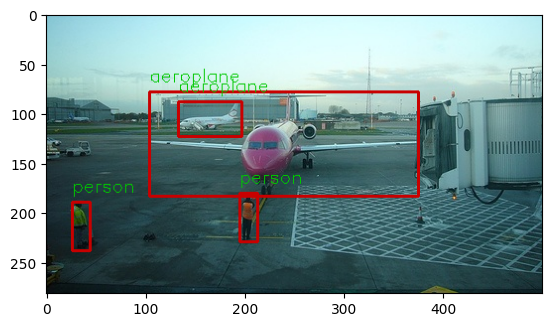

In [13]:
plt.imshow(image)

In [14]:
print(image.shape)

(281, 500, 3)


In [15]:
object_semantic_image = np.array(Image.open(semantic_image_path))
ids = np.unique(object_semantic_image)
ids = ids[(ids!=0) & (ids!=255)] 

instances = [np.array((object_semantic_image==obj_id)) for obj_id in  ids]
# instances = int(instances)
instances

[array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(281, 500)),
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(281, 500)),
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [

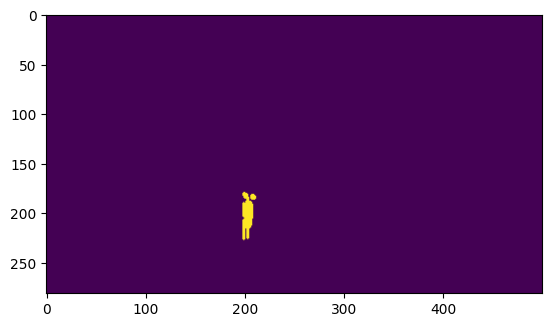

In [16]:
plt.imshow(instances[2])

In [17]:
intersection = np.logical_and(masks[0], instances[2]).sum()
union = np.logical_or(masks[0], instances[2]).sum()

iou = intersection / union

In [18]:
iou

np.float64(0.6429872495446266)